data shape = (300,)
first 10 values = [115.85679142 152.26153716 178.87449059 162.93500815 107.02820697
 105.19141146 118.38288501 125.3769803  102.88054011 206.71326136] ...


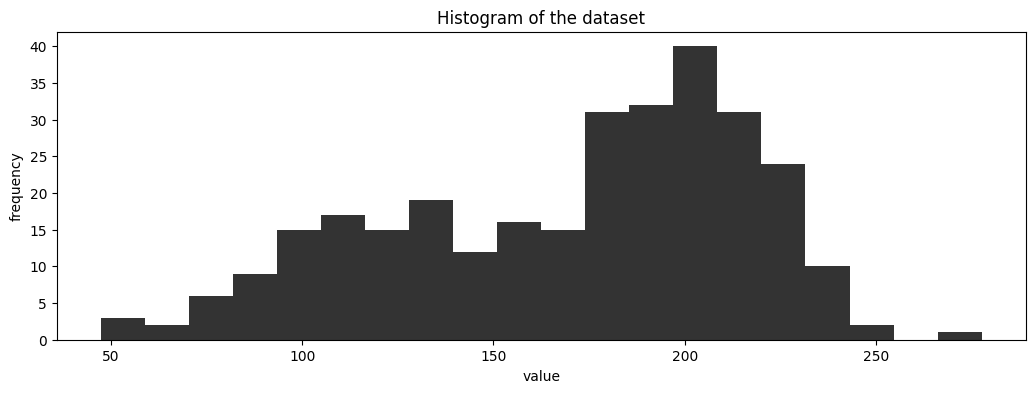

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [w, centers, sds]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\P
ython311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 3_000 tune and 5_000 draw iterations (6_000 + 10_000 draws total) took 31734 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


              mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
w[0]          0.38  0.05    0.28     0.47       0.00     0.00   3079.56   
w[1]          0.62  0.05    0.53     0.72       0.00     0.00   3079.56   
centers[0]  120.23  5.64  109.96   130.96       0.11     0.09   3071.62   
centers[1]  199.56  2.59  194.92   204.67       0.04     0.03   3465.62   
sds[0]       30.18  4.04   22.90    37.85       0.08     0.06   3057.56   
sds[1]       22.83  1.93   19.13    26.35       0.03     0.02   3871.36   

            ess_tail  r_hat  
w[0]         3497.40    1.0  
w[1]         3497.40    1.0  
centers[0]   3341.91    1.0  
centers[1]   5058.07    1.0  
sds[0]       3454.92    1.0  
sds[1]       4943.45    1.0  


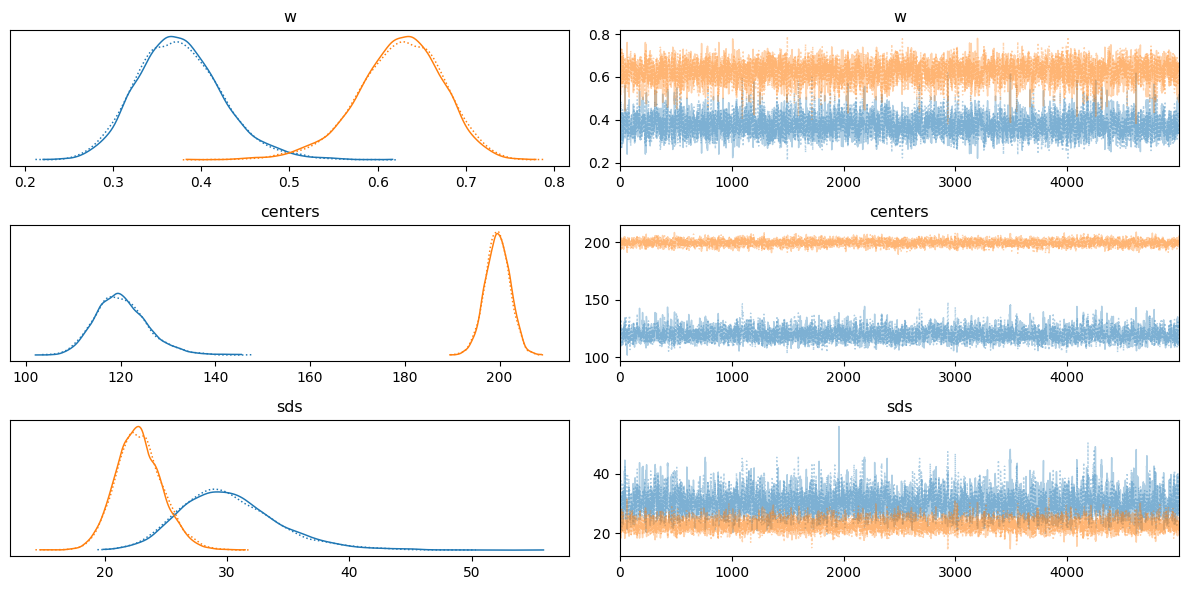

posterior mean centers = [120.23209081 199.56433894]
posterior mean sds     = [30.18156518 22.82526417]
posterior mean weights = [0.37561368 0.62438632]


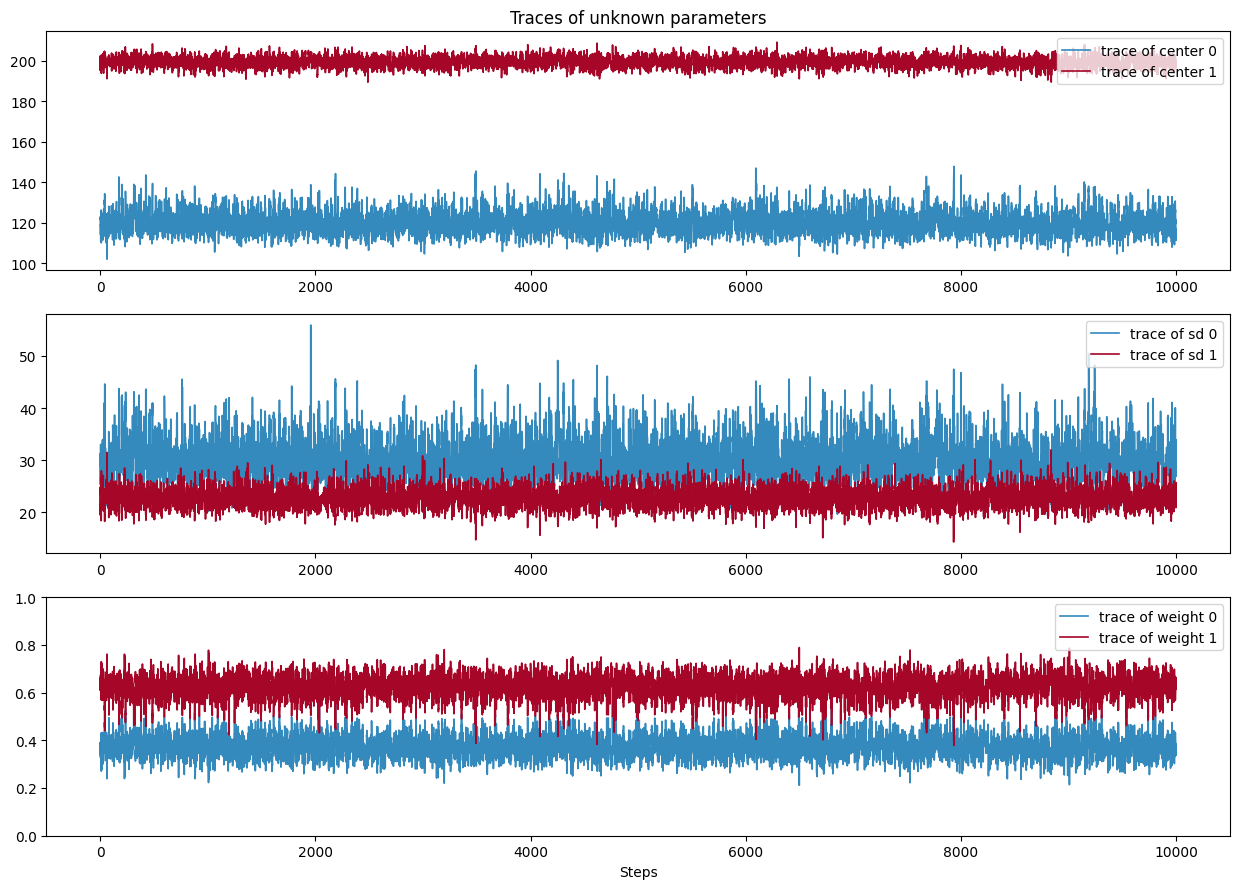

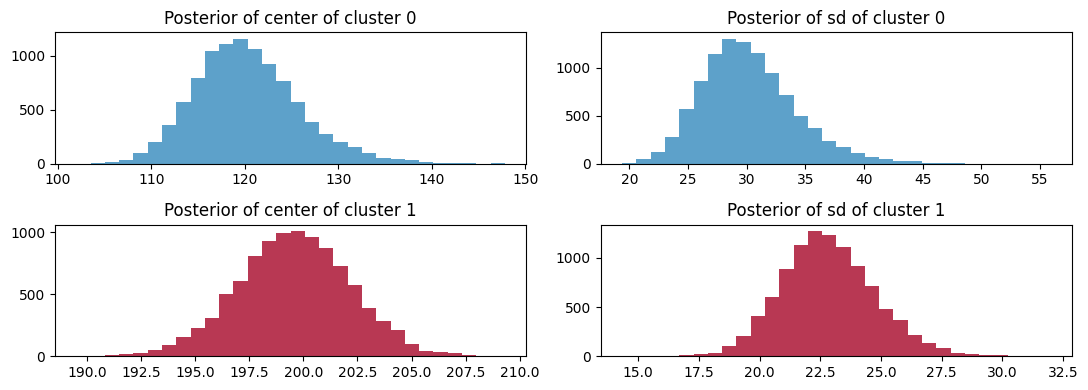

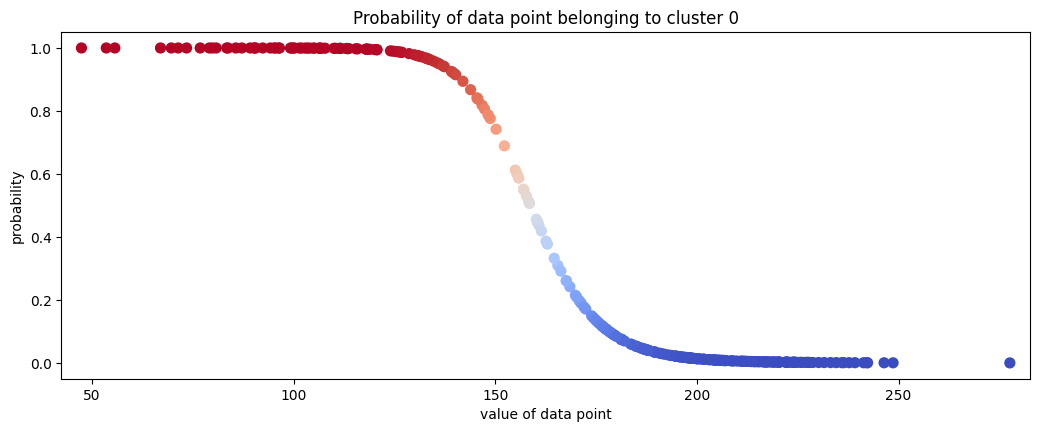

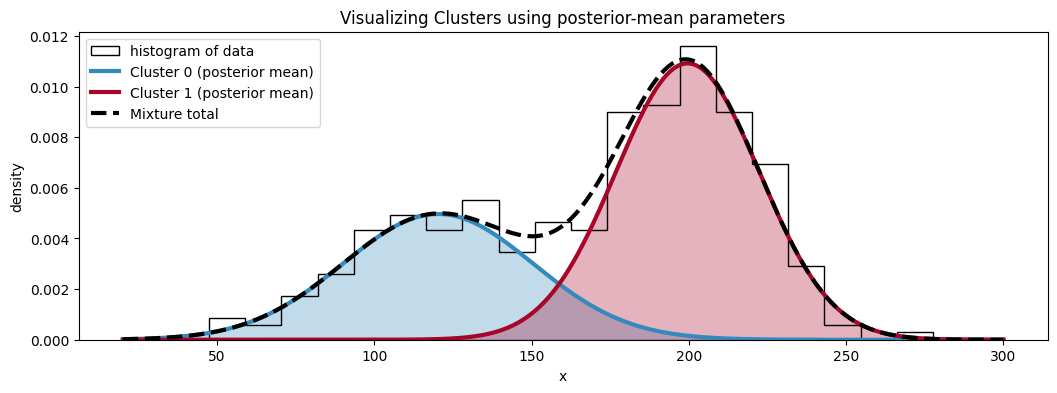

Sequential sampling (2 chains in 1 job)
Metropolis: [x]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\P
ython311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 2_000 tune and 5_000 draw iterations (4_000 + 10_000 draws total) took 8 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


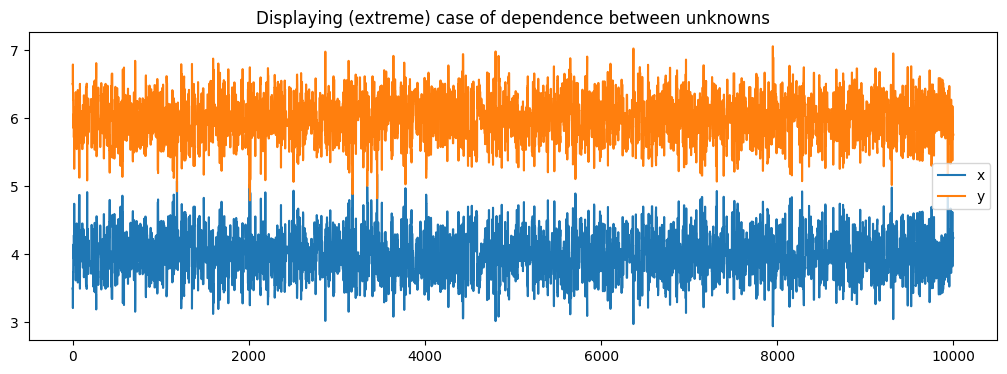

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats

# =========================================
# 0. 乱数シード
# =========================================
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# =========================================
# 1. データ読み込み
# =========================================
data = np.loadtxt("mixture_data.csv", delimiter=",")

# 1次元ベクトルでない場合の保険
data = np.asarray(data).reshape(-1)

print("data shape =", data.shape)
print("first 10 values =", data[:10], "...")

# =========================================
# 2. データのヒストグラム
# =========================================
plt.figure(figsize=(12.5, 4))
plt.hist(data, bins=20, color="k", histtype="stepfilled", alpha=0.8)
plt.title("Histogram of the dataset")
plt.ylim([0, None])
plt.xlabel("value")
plt.ylabel("frequency")
plt.show()

# =========================================
# 3. 2成分ガウス混合モデル
#    現行PyMCでは、明示的なassignment変数を置くより
#    mixtureとして周辺化した書き方のほうが安定しやすい
# =========================================
with pm.Model() as model:
    # 混合比
    w = pm.Dirichlet("w", a=np.array([1.0, 1.0]))

    # 各クラスタの平均
    centers = pm.Normal(
        "centers",
        mu=np.array([120.0, 190.0]),
        sigma=np.array([10.0, 10.0]),
        shape=2
    )

    # 各クラスタの標準偏差
    sds = pm.Uniform("sds", lower=0.0, upper=100.0, shape=2)

    # 各成分分布
    components = pm.Normal.dist(mu=centers, sigma=sds, shape=2)

    # 観測モデル
    obs = pm.Mixture("obs", w=w, comp_dists=components, observed=data)

    # サンプリング
    idata = pm.sample(
        draws=5000,
        tune=3000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True
    )

# =========================================
# 4. サマリー表示
# =========================================
print(az.summary(idata, var_names=["w", "centers", "sds"], round_to=2))

# =========================================
# 5. トレースプロット
# =========================================
az.plot_trace(idata, var_names=["w", "centers", "sds"])
plt.tight_layout()
plt.show()

# =========================================
# 6. 事後サンプル取り出し
# =========================================
posterior_centers = (
    idata.posterior["centers"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (2, n_samples) ではなく xarray依存なので後で整理

posterior_sds = (
    idata.posterior["sds"]
    .stack(sample=("chain", "draw"))
    .values
)

posterior_w = (
    idata.posterior["w"]
    .stack(sample=("chain", "draw"))
    .values
)

# xarray -> numpyの次元を確認して整形
# 期待形状:
# centers: (chain, draw, 2) -> stack後は (2, sample) か (sample, 2) 相当
# 安全のため転置を調整
if posterior_centers.shape[0] == 2:
    center_samples = posterior_centers.T
else:
    center_samples = posterior_centers

if posterior_sds.shape[0] == 2:
    sd_samples = posterior_sds.T
else:
    sd_samples = posterior_sds

if posterior_w.shape[0] == 2:
    w_samples = posterior_w.T
else:
    w_samples = posterior_w

# =========================================
# 7. ラベルスイッチ対策
#    混合モデルではサンプルごとにクラスタ0/1が入れ替わることがあるので、
#    centerの小さい方をcluster 0、大きい方をcluster 1に並べ替える
# =========================================
ordered_center_samples = np.zeros_like(center_samples)
ordered_sd_samples = np.zeros_like(sd_samples)
ordered_w_samples = np.zeros_like(w_samples)

for i in range(center_samples.shape[0]):
    order = np.argsort(center_samples[i])
    ordered_center_samples[i] = center_samples[i][order]
    ordered_sd_samples[i] = sd_samples[i][order]
    ordered_w_samples[i] = w_samples[i][order]

# 事後平均
posterior_center_means = ordered_center_samples.mean(axis=0)
posterior_sd_means = ordered_sd_samples.mean(axis=0)
posterior_w_means = ordered_w_samples.mean(axis=0)

print("posterior mean centers =", posterior_center_means)
print("posterior mean sds     =", posterior_sd_means)
print("posterior mean weights =", posterior_w_means)

# 色
colors = ["#348ABD", "#A60628"]
lw = 1.2

# =========================================
# 8. 中心・標準偏差・混合比のトレース
# =========================================
plt.figure(figsize=(12.5, 9))

plt.subplot(311)
plt.plot(ordered_center_samples[:, 0], label="trace of center 0", c=colors[0], lw=lw)
plt.plot(ordered_center_samples[:, 1], label="trace of center 1", c=colors[1], lw=lw)
plt.title("Traces of unknown parameters")
plt.legend(loc="upper right")

plt.subplot(312)
plt.plot(ordered_sd_samples[:, 0], label="trace of sd 0", c=colors[0], lw=lw)
plt.plot(ordered_sd_samples[:, 1], label="trace of sd 1", c=colors[1], lw=lw)
plt.legend(loc="upper right")

plt.subplot(313)
plt.plot(ordered_w_samples[:, 0], label="trace of weight 0", c=colors[0], lw=lw)
plt.plot(ordered_w_samples[:, 1], label="trace of weight 1", c=colors[1], lw=lw)
plt.ylim(0, 1)
plt.xlabel("Steps")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# =========================================
# 9. 事後分布ヒストグラム
# =========================================
plt.figure(figsize=(11.0, 4))

plt.subplot(2, 2, 1)
plt.title("Posterior of center of cluster 0")
plt.hist(ordered_center_samples[:, 0], color=colors[0], bins=30, histtype="stepfilled", alpha=0.8)

plt.subplot(2, 2, 2)
plt.title("Posterior of sd of cluster 0")
plt.hist(ordered_sd_samples[:, 0], color=colors[0], bins=30, histtype="stepfilled", alpha=0.8)

plt.subplot(2, 2, 3)
plt.title("Posterior of center of cluster 1")
plt.hist(ordered_center_samples[:, 1], color=colors[1], bins=30, histtype="stepfilled", alpha=0.8)

plt.subplot(2, 2, 4)
plt.title("Posterior of sd of cluster 1")
plt.hist(ordered_sd_samples[:, 1], color=colors[1], bins=30, histtype="stepfilled", alpha=0.8)

plt.tight_layout()
plt.show()

# =========================================
# 10. 各データ点が cluster 0 に属する確率を近似計算
#     assignment を明示サンプリングしていないので、
#     事後平均パラメータを使ってベイズ則で近似する
# =========================================
mu0, mu1 = posterior_center_means
sd0, sd1 = posterior_sd_means
w0, w1 = posterior_w_means

lik0 = w0 * stats.norm.pdf(data, loc=mu0, scale=sd0)
lik1 = w1 * stats.norm.pdf(data, loc=mu1, scale=sd1)

prob_cluster0 = lik0 / (lik0 + lik1)

plt.figure(figsize=(12.5, 4.5))
plt.scatter(data, prob_cluster0, c=prob_cluster0, s=50, cmap="coolwarm")
plt.ylim(-0.05, 1.05)
plt.xlim(data.min() - 5, data.max() + 5)
plt.title("Probability of data point belonging to cluster 0")
plt.ylabel("probability")
plt.xlabel("value of data point")
plt.show()

# =========================================
# 11. 事後平均パラメータによる混合分布の可視化
# =========================================
x = np.linspace(min(20, data.min() - 10), max(300, data.max() + 10), 500)

plt.figure(figsize=(12.5, 4))
plt.hist(
    data,
    bins=20,
    histtype="step",
    density=True,
    color="k",
    lw=2,
    label="histogram of data"
)

y0 = w0 * stats.norm.pdf(x, loc=mu0, scale=sd0)
y1 = w1 * stats.norm.pdf(x, loc=mu1, scale=sd1)

plt.plot(x, y0, label="Cluster 0 (posterior mean)", lw=3, color=colors[0])
plt.fill_between(x, y0, color=colors[0], alpha=0.3)

plt.plot(x, y1, label="Cluster 1 (posterior mean)", lw=3, color=colors[1])
plt.fill_between(x, y1, color=colors[1], alpha=0.3)

plt.plot(x, y0 + y1, label="Mixture total", lw=3, color="black", linestyle="--")

plt.legend(loc="upper left")
plt.title("Visualizing Clusters using posterior-mean parameters")
plt.xlabel("x")
plt.ylabel("density")
plt.show()

# =========================================
# 12. 依存の強い2変数の例
#     元コード末尾の小例も現行PyMCで書き直し
# =========================================
with pm.Model() as dep_model:
    x_var = pm.Normal("x", mu=4, sigma=np.sqrt(1 / 10))
    y_var = pm.Deterministic("y", 10 - x_var)

    dep_idata = pm.sample(
        draws=5000,
        tune=2000,
        chains=2,
        cores=1,
        step=pm.Metropolis(),
        random_seed=RANDOM_SEED,
        return_inferencedata=True
    )

x_trace = dep_idata.posterior["x"].stack(sample=("chain", "draw")).values
y_trace = dep_idata.posterior["y"].stack(sample=("chain", "draw")).values

plt.figure(figsize=(12.5, 4))
plt.plot(x_trace, label="x")
plt.plot(y_trace, label="y")
plt.title("Displaying (extreme) case of dependence between unknowns")
plt.legend()
plt.show()